In [1]:
from datasets import load_dataset
from tiktoken import encoding_for_model
from torch import nn
import torch.nn.functional as F
import torch

In [2]:
enc = encoding_for_model("gpt-2")

def tokenize(x):
    ids = enc.encode_ordinary(x["text"])                                                                                                        
    ids.append(enc.eot_token)          # document boundary <|endoftext|>                                                                             
    return {"input_ids": ids}

enc

<Encoding 'gpt2'>

In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(
            self,
            embedding_dim: int = 768,
            context_size: int = 512,
            q_dim: int = 384,
            k_dim: int | None = None,
            v_dim: int = 420,
            num_heads: int = 12,
            bias: bool = True,
            dropout: float = 0.1
        ):

        super().__init__()

        assert q_dim % num_heads == 0
        assert v_dim % num_heads == 0
        assert dropout <= 1.0 and dropout >= 0.0
        if k_dim is not None:
            assert k_dim % num_heads == 0

        self.k_dim = k_dim if k_dim is not None else q_dim
        self.q_dim = q_dim
        self.embedding_dim = embedding_dim
        self.context_size = context_size
        self.v_dim = v_dim
        self.num_heads = num_heads
        self.bias = bias
        self.dropout = dropout

        self.W_q = nn.Linear(self.embedding_dim, self.q_dim, bias=self.bias)
        self.W_k = nn.Linear(self.embedding_dim, self.k_dim, bias=self.bias)
        self.W_v = nn.Linear(self.embedding_dim, self.v_dim, bias=self.bias)

        self.W_out = nn.Linear(self.v_dim, self.embedding_dim, bias=self.bias)

        # mask = torch.triu(torch.ones(self.context_size, self.context_size), diagonal=1).bool()
        # self.register_buffer("mask", mask)

    def forward(self, x: torch.Tensor):
        # x_dim = (batch, context, embedding_dim)
        q: torch.Tensor = self.W_q(x) # (batch, context, q_dim)
        k: torch.Tensor = self.W_k(x) # (batch, context, k_dim)
        v: torch.Tensor = self.W_v(x) # (batch, context, v_dim)

        batch_size = x.shape[0]
        seq_len = x.shape[1]

        q = q.reshape(batch_size, seq_len, self.num_heads, self.q_dim // self.num_heads)
        q = q.transpose(1 , 2) # q_dim = (batch, num_heads, seq_len, head_dim)

        k = k.reshape(batch_size, seq_len, self.num_heads, self.k_dim // self.num_heads)
        k = k.transpose(1 , 2) # k_dim = (batch, num_heads, seq_len, head_dim)

        v = v.reshape(batch_size, seq_len, self.num_heads, self.v_dim // self.num_heads)
        v = v.transpose(1 , 2) # k_dim = (batch, num_heads, seq_len, value_head_dim)

        # scores = q @ k.transpose(-1, -2)
        # scores = scores / math.sqrt(self.q_dim // self.num_heads)
        # scores = torch.masked_fill(scores, self.mask[:seq_len, :seq_len], float("-inf"))
        # weights = torch.softmax(scores, dim = -1) # weights_dim = (batch, num_heads, seq_len, seq_len)

        out = F.scaled_dot_product_attention(q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=True)

        out = out.transpose(1, 2).reshape(batch_size, seq_len, self.v_dim) # (batch, seq_len, v_dim)
        out: torch.Tensor = self.W_out(out)  # (batch, seq_len, embedding_dim)

        return out        



In [4]:
class FeedForwardLayer(nn.Module):
    def __init__(
        self,
        embedding_dim: int = 768,
        hidden_dim: int = 3072,
        dropout: float = 0.1
    ):
        super().__init__()

        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.activation = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, embedding_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        # x_dim = (batch, seq, embedding_dim)
        x = self.fc1(x) # (batch, seq, hidden)
        x = self.activation(x) # (batch, seq, hidden)
        x = self.fc2(x) # (batch, seq, embedding_dim)
        x = self.drop(x)
        return x

In [5]:
class TransformerBlock(nn.Module):
    def __init__(
        self,
        embedding_dim: int = 768,
        context_size: int = 512,
        q_dim: int = 384,
        k_dim: int | None = None,
        v_dim: int = 420,
        num_heads: int = 12,
        ff_hidden_dim: int = 3072,
    ):
        super().__init__()

        self.ln1 = nn.LayerNorm(embedding_dim)
        self.attention = MultiHeadAttention(
            embedding_dim=embedding_dim,
            context_size=context_size,
            q_dim=q_dim,
            k_dim=k_dim,
            v_dim=v_dim,
            num_heads=num_heads,
        )

        self.ln2 = nn.LayerNorm(embedding_dim)
        self.ff = FeedForwardLayer(
            embedding_dim=embedding_dim,
            hidden_dim=ff_hidden_dim,
        )

    def forward(self, x: torch.Tensor):
        x = x + self.attention(self.ln1(x))
        x = x + self.ff(self.ln2(x))

        return x

In [6]:
class GPT(nn.Module):
    def __init__(self,
        embedding_dim: int = 768,
        q_dim: int = 768,
        k_dim: int | None = None,
        v_dim: int = 768,
        context_size: int = 512,
        num_heads: int = 12,
        ff_hidden_dim: int = 3072,
        vocab_size: int = encoding_for_model("gpt-2").n_vocab,
        transformer_blocks: int = 12,
        dropout: float = 0.1
    ):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embedding_dim)
        self.positional_embedding = nn.Embedding(context_size, embedding_dim)


        self.blocks = nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dim, 
                    context_size, 
                    q_dim, k_dim, v_dim, 
                    num_heads, ff_hidden_dim
                )

                for _ in range (0, transformer_blocks)
            ]
        )

        self.input_drop = nn.Dropout(dropout)

        self.ln_final = nn.LayerNorm(embedding_dim)

        self.lm_head = nn.Linear(
            embedding_dim,
            vocab_size,
            bias=False,
        )

        self.ctx_len = context_size

    def forward(self, input_ids: torch.Tensor):
        _, T = input_ids.shape

        positions = torch.arange(
            T,
            device=input_ids.device,
        )

        x = self.token_embedding(input_ids)
        x = x + self.positional_embedding(positions)

        x = self.input_drop(x)

        x = self.blocks(x)

        x = self.ln_final(x)

        logits = self.lm_head(x)

        return logits

    def params(self) -> int:
        return sum(p.numel() for p in self.parameters())


In [7]:
model = GPT()

print(f"Model size = {((model.params() * 4) / 1024) / 1024} MB")

Model size = 620.4375 MB


In [8]:
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# --- config ---
DATASET_ID = "roneneldan/TinyStories"
CONTEXT_LEN = 512          # must match GPT context_size
BATCH_SIZE = 4             # fits 6GB VRAM, use 8 on 12GB Colab
SEED = 42
MAX_TRAIN_STORIES = 80000  # ~60M tokens, ~3-4h on your 4050. Streaming = no RAM blowup
MAX_VAL_STORIES = 5000

print(f"Loading {DATASET_ID} (streaming) ...")
# streaming=True -> IterableDataset, no full download into RAM
train_raw = load_dataset(DATASET_ID, streaming=True, split="train")
test_raw = load_dataset(DATASET_ID, streaming=True, split="validation")

# shuffle + take subset for 3-4h run (streaming: take() is lazy)
train_raw = train_raw.shuffle(seed=SEED, buffer_size=10000).take(MAX_TRAIN_STORIES)
test_raw = test_raw.shuffle(seed=SEED, buffer_size=1000).take(MAX_VAL_STORIES)

print(f"  train: {MAX_TRAIN_STORIES:,} stories (streaming, shuffled)")
print(f"  test : {MAX_VAL_STORIES:,} stories (streaming, shuffled)")
print(f"  streaming: IterableDataset, iterates on-the-fly, ~0 RAM")


Loading roneneldan/TinyStories (streaming) ...
  train: 80,000 stories (streaming, shuffled)
  test : 5,000 stories (streaming, shuffled)
  streaming: IterableDataset, iterates on-the-fly, ~0 RAM


In [9]:
# tokenize stories -> ids (streaming map is lazy, no compute yet)
print("Tokenizing (streaming, lazy) ...")

def tokenize_fn(example):
    ids = enc.encode_ordinary(example["text"])
    ids.append(enc.eot_token)
    return {"input_ids": ids}

train_tok = train_raw.map(tokenize_fn, remove_columns=["text"])
test_tok = test_raw.map(tokenize_fn, remove_columns=["text"])

print("  tokenized streams ready (still lazy, will run during chunking)")


Tokenizing (streaming, lazy) ...
  tokenized streams ready (still lazy, will run during chunking)


In [10]:
# chunk token streams into CONTEXT_LEN blocks (streaming, memory efficient)
print(f"Chunking into blocks of {CONTEXT_LEN} (streaming) ...")

def build_chunks_streaming(tokenized_stream, ctx_len, desc):
    chunks = []
    buf = []
    total_tokens = 0
    for ex in tqdm(tokenized_stream, desc=desc):
        buf.extend(ex["input_ids"])
        total_tokens += len(ex["input_ids"])
        while len(buf) >= ctx_len:
            chunks.append(buf[:ctx_len])
            buf = buf[ctx_len:]
    # drop remainder (< ctx_len)
    print(f"  {desc}: {total_tokens:,} tokens -> {len(chunks):,} chunks, dropped {len(buf)} remainder")
    return chunks

train_chunks = build_chunks_streaming(train_tok, CONTEXT_LEN, desc="  train")
test_chunks = build_chunks_streaming(test_tok, CONTEXT_LEN, desc="  test")

print(f"  train chunks: {len(train_chunks):,} ({len(train_chunks)*CONTEXT_LEN:,} tokens)")
print(f"  test  chunks: {len(test_chunks):,} ({len(test_chunks)*CONTEXT_LEN:,} tokens)")


Chunking into blocks of 512 (streaming) ...


  train: 0it [00:00, ?it/s]

    train: 17,874,834 tokens -> 34,911 chunks, dropped 402 remainder


  test: 0it [00:00, ?it/s]

    test: 1,011,076 tokens -> 1,974 chunks, dropped 388 remainder
  train chunks: 34,911 (17,874,432 tokens)
  test  chunks: 1,974 (1,010,688 tokens)


In [11]:
class LMDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        ids = torch.tensor(self.chunks[idx], dtype=torch.long)
        return {"input_ids": ids, "labels": ids.clone()}

train_ds = LMDataset(train_chunks)
test_ds = LMDataset(test_chunks)

print(f"Dataset ready")
print(f"  train_ds: {len(train_ds):,} samples")
print(f"  test_ds : {len(test_ds):,} samples")
print(f"  sample shape: {train_ds[0]['input_ids'].shape}")


Dataset ready
  train_ds: 34,911 samples
  test_ds : 1,974 samples
  sample shape: torch.Size([512])


In [12]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"DataLoaders (from streaming)")
print(f"  train batches: {len(train_loader):,}  (batch={BATCH_SIZE} x ctx={CONTEXT_LEN} = {BATCH_SIZE*CONTEXT_LEN:,} tokens/batch)")
print(f"  test  batches: {len(test_loader):,}")
print(f"  tokens / epoch: {len(train_loader)*BATCH_SIZE*CONTEXT_LEN:,}")
print(f"  est. time / epoch on 4050 bf16 (~5.2k tok/s): {len(train_loader)*BATCH_SIZE*CONTEXT_LEN/5283/60:.1f} min")

batch = next(iter(train_loader))
print(f"\nSanity check")
print(f"  input_ids: {batch['input_ids'].shape}  dtype={batch['input_ids'].dtype}")
print(f"  labels   : {batch['labels'].shape}")
print(f"  decoded sample: {enc.decode(batch['input_ids'][0][:40].tolist())[:120]!r} ...")


DataLoaders (from streaming)
  train batches: 8,728  (batch=4 x ctx=512 = 2,048 tokens/batch)
  test  batches: 494
  tokens / epoch: 17,874,944
  est. time / epoch on 4050 bf16 (~5.2k tok/s): 56.4 min

Sanity check
  input_ids: torch.Size([4, 512])  dtype=torch.int64
  labels   : torch.Size([4, 512])
  decoded sample: 'Timmy went home and showed his mom the flyer. She asked him what happened and he told her everything. She hugged him and' ...


In [13]:
import matplotlib.pyplot as plt
from contextlib import nullcontext

# --- training config ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 3e-4
EPOCHS = 1              # 1 epoch ~60M tokens ~3h on 4050 (bf16). Try 3 for full run
WEIGHT_DECAY = 0.1
LOG_EVERY = 100         # log train loss every N steps
USE_AMP = (DEVICE.type == "cuda")  # bf16 autocast on GPU

# --- inference preview config ---
INFER_PROMPT = "Once upon a time there was a little girl named Lily"
INFER_EVERY = 2000      # run inference every N steps
INFER_TOKENS = 80       # how many tokens to generate

# re-init model on correct device (overwrites earlier cpu model)
model = GPT().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

print(f"Device      : {DEVICE}")
print(f"Model params: {model.params():,} ({model.params()*4/1024/1024:.1f} MB fp32)")
print(f"LR          : {LR} | epochs: {EPOCHS} | batch: {BATCH_SIZE} | ctx: {CONTEXT_LEN}")
print(f"AMP bf16    : {USE_AMP}")
print(f"Train batches: {len(train_loader):,} | Val batches: {len(test_loader):,}")
print(f"Inference   : every {INFER_EVERY} steps, prompt={INFER_PROMPT!r}")


Device      : cuda
Model params: 162,643,968 (620.4 MB fp32)
LR          : 0.0003 | epochs: 1 | batch: 4 | ctx: 512
AMP bf16    : True
Train batches: 8,728 | Val batches: 494
Inference   : every 2000 steps, prompt='Once upon a time there was a little girl named Lily'


In [15]:
train_history = []
val_history = []
step_history = []  # for finer curve
infer_history = [] # keep generated texts to see progress

def generate_preview(prompt):
    model.eval()
    with torch.no_grad():
        ids = enc.encode(prompt)[:CONTEXT_LEN]
        inp = torch.tensor(ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
        ctx = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if USE_AMP else nullcontext()
        with ctx:
            for _ in range(INFER_TOKENS):
                context = inp[:, -CONTEXT_LEN:]
                logits = model(context)
                nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                inp = torch.cat([inp, nxt], dim=1)
                if nxt.item() == enc.eot_token:
                    break
        text = enc.decode(inp[0].tolist())
    model.train()
    return text

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]")

    for step, batch in enumerate(pbar, 1):
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        ctx = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if USE_AMP else nullcontext()
        with ctx:
            logits = model(input_ids)
            loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        step_history.append(loss.item())

        if step % LOG_EVERY == 0:
            avg = running_loss / step
            pbar.set_postfix({"loss": f"{avg:.4f}", "step_loss": f"{loss.item():.4f}"})

        # ---- inference preview every N steps ----
        if step % INFER_EVERY == 0:
            txt = generate_preview(INFER_PROMPT)
            infer_history.append((epoch, step, txt))
            print(f"\n--- Inference @ epoch {epoch} step {step:,} ---")
            print(txt[:500])
            print("-" * 60)

    avg_train = running_loss / len(train_loader)
    train_history.append(avg_train)

    # ---- validate ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]"):
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            ctx = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if USE_AMP else nullcontext()
            with ctx:
                logits = model(input_ids)
                loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))
            val_loss += loss.item()
    val_loss /= len(test_loader)
    val_history.append(val_loss)

    print(f"\nEpoch {epoch}/{EPOCHS} | train loss: {avg_train:.4f} | val loss: {val_loss:.4f}")

    # inference also at epoch end (so you see progress even if steps < INFER_EVERY)
    txt = generate_preview(INFER_PROMPT)
    infer_history.append((epoch, "end", txt))
    print(f"--- Inference @ epoch {epoch} end ---")
    print(txt[:600])
    print("-" * 60)

print("Training done")


Epoch 1/1 [train]:   0%|          | 0/8728 [00:00<?, ?it/s]


--- Inference @ epoch 1 step 2,000 ---
Once upon a time there was a little girl named Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily
------------------------------------------------------------

--- Inference @ epoch 1 step 4,000 ---
Once upon a time there was a little girl named Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily 

Epoch 1/1 [val]:   0%|          | 0/494 [00:00<?, ?it/s]


Epoch 1/1 | train loss: 0.0366 | val loss: 0.0087
--- Inference @ epoch 1 end ---
Once upon a time there was a little girl named Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily
------------------------------------------------------------
Training done


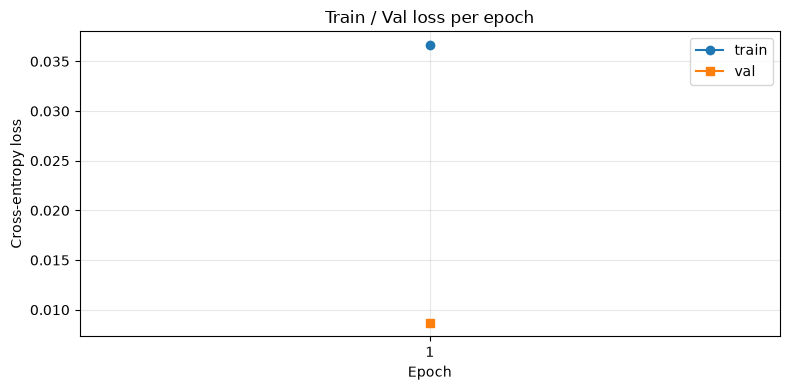

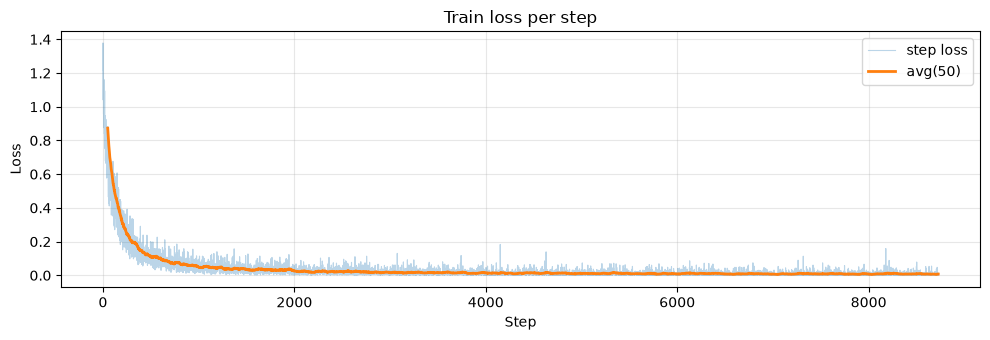

Final | train: 0.0366 | val: 0.0087


In [16]:
# --- loss curves ---
plt.figure(figsize=(8, 4))

# epoch-level curves
epochs = range(1, len(train_history) + 1)
plt.plot(epochs, train_history, marker="o", label="train")
plt.plot(epochs, val_history, marker="s", label="val")
plt.xticks(epochs)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Train / Val loss per epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# finer step curve (train loss smoothing)
plt.figure(figsize=(10, 3.5))
plt.plot(step_history, alpha=0.3, linewidth=0.8, label="step loss")
# moving average for readability
if len(step_history) > 50:
    window = 50
    avg = [sum(step_history[i-window:i])/window for i in range(window, len(step_history))]
    plt.plot(range(window, len(step_history)), avg, linewidth=2, label=f"avg({window})")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train loss per step")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final | train: {train_history[-1]:.4f} | val: {val_history[-1]:.4f}")


In [17]:
def inference(model: GPT, input_text: str, max_new_tokens: int = 100, temperature: float = 0.8, top_k: int = 50) -> str:
    """Generate with temperature + top-k sampling. temp=0 => greedy."""
    device = next(model.parameters()).device
    tokens = enc.encode(input_text)
    tokens = tokens[:model.ctx_len]
    input_ids = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = input_ids[:, -model.ctx_len:]
            logits = model(context)[:, -1, :]

            # greedy if temp == 0
            if temperature == 0 or temperature is None:
                next_token = logits.argmax(dim=-1, keepdim=True)
            else:
                logits = logits / temperature
                if top_k is not None and top_k > 0:
                    v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                    logits[logits < v[:, [-1]]] = -float("inf")
                probs = torch.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)

            input_ids = torch.cat([input_ids, next_token], dim=1)
            if next_token.item() == enc.eot_token:
                break
    return enc.decode(input_ids[0].tolist())


In [26]:
# try different sampling
print("-- greedy (temp=0) --")
print(inference(model, "Once upon a time there was a little girl named Lily", temperature=0, top_k=50))
print("\n-- creative (temp=0.8, top_k=50) --")
print(inference(model, "Once upon a time there was a little girl named Lily", temperature=0.8, top_k=50))
print("\n-- more random (temp=1.2, top_k=100) --")
print(inference(model, "Hello", temperature=3, top_k=100))


-- greedy (temp=0) --
Once upon a time there was a little girl named Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily

-- creative (temp=0.8, top_k=50) --
Once upon a time there was a little girl named Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Lily Li

In [19]:
from pathlib import Path

# --- save model weights ---
SAVE_PATH = "gpt_tinystories.pt"
torch.save(model.state_dict(), SAVE_PATH)
size_mb = Path(SAVE_PATH).stat().st_size / 1024 / 1024
print(f"Saved weights to {SAVE_PATH} ({size_mb:.1f} MB)")
print(f"Params: {model.params():,}")

# save full checkpoint (to resume training)
CKPT_PATH = "gpt_tinystories_ckpt.pt"
torch.save({
    "model": model.state_dict(),
    "optimizer": optimizer.state_dict(),
    "config": {"ctx": CONTEXT_LEN, "vocab": enc.n_vocab},
}, CKPT_PATH)
print(f"Saved checkpoint to {CKPT_PATH} ({Path(CKPT_PATH).stat().st_size/1024/1024:.1f} MB)")

# to load later:
# model = GPT().to(DEVICE)
# model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
# model.eval()


Saved weights to gpt_tinystories.pt (620.5 MB)
Params: 162,643,968
Saved checkpoint to gpt_tinystories_ckpt.pt (1861.5 MB)
